In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/datasets/tejasbhalekar1/sample/b.png
/kaggle/input/datasets/tejasbhalekar1/sample/test_digit3.png
/kaggle/input/datasets/tejasbhalekar1/sample/test_digit.png
/kaggle/input/datasets/tejasbhalekar1/sample/z.png
/kaggle/input/datasets/tejasbhalekar1/sample/s.png


In [2]:
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense
from PIL import Image

# 1. Download the MNIST dataset
print("Downloading data...")
mnist = tf.keras.datasets.mnist
(x_train, y_train), (x_test, y_test) = mnist.load_data()

print(f"✅ Loaded {len(x_train)} training images and {len(x_test)} test images.")

2026-03-06 05:26:53.105826: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1772774813.312026      55 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1772774813.369281      55 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1772774813.839797      55 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1772774813.839835      55 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1772774813.839839      55 computation_placer.cc:177] computation placer alr

11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
✅ Loaded 60000 training images and 10000 test images.


In [3]:
# 1. Normalize the pixel values (scale from 0-255 down to 0.0-1.0)
x_train = x_train / 255.0
x_test = x_test / 255.0

# 2. Reshape to include the color channel (1 = Grayscale)
x_train = x_train.reshape(-1, 28, 28, 1)
x_test = x_test.reshape(-1, 28, 28, 1)

print("✅ Data preprocessed and reshaped for the CNN!")

✅ Data preprocessed and reshaped for the CNN!


In [4]:
# 1. Build the Sequential model
model = Sequential([
    # The 'Eyes' (Feature Extraction)
    Conv2D(32, (3, 3), activation='relu', input_shape=(28, 28, 1)),
    MaxPooling2D((2, 2)),
    
    # The 'Logic' (Decision Making)
    Flatten(),
    Dense(128, activation='relu'),
    Dense(10, activation='softmax') # 10 outputs for digits 0-9
])

# 2. Compile the model
model.compile(optimizer='adam', 
              loss='sparse_categorical_crossentropy', 
              metrics=['accuracy'])

print("✅ CNN Architecture Built!")
model.summary()

✅ CNN Architecture Built!


/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)
2026-03-06 05:27:18.227872: E external/local_xla/xla/stream_executor/cuda/cuda_platform.cc:51] failed call to cuInit: INTERNAL: CUDA error: Failed call to cuInit: UNKNOWN ERROR (303)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 26, 26, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 13, 13, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 5408)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │       692,352 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 693,962 (2.65 MB)

 Trainable params: 693,962 (2.65 MB)

 Non-trainable params: 0 (0.00 B)

In [5]:
# 1. Train the model (5 Epochs)
print("🧠 Training the AI... Please wait.")
history = model.fit(x_train, y_train, epochs=5, validation_split=0.1)

# 2. Evaluate on the Test Exam
print("\n📝 Grading the final exam...")
test_loss, test_accuracy = model.evaluate(x_test, y_test)

print("-" * 30)
print(f"🎓 FINAL TEST ACCURACY: {test_accuracy * 100:.2f}%")
print("-" * 30)

🧠 Training the AI... Please wait.
Epoch 1/5
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 22s 12ms/step - accuracy: 0.9055 - loss: 0.3146 - val_accuracy: 0.9823 - val_loss: 0.0619
Epoch 2/5
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 20s 12ms/step - accuracy: 0.9815 - loss: 0.0622 - val_accuracy: 0.9848 - val_loss: 0.0559
Epoch 3/5
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 20s 12ms/step - accuracy: 0.9895 - loss: 0.0340 - val_accuracy: 0.9867 - val_loss: 0.0497
Epoch 4/5
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 20s 12ms/step - accuracy: 0.9933 - loss: 0.0221 - val_accuracy: 0.9877 - val_loss: 0.0455
Epoch 5/5
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 20s 12ms/step - accuracy: 0.9960 - loss: 0.0127 - val_accuracy: 0.9858 - val_loss: 0.0589

📝 Grading the final exam...
313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.9806 - loss: 0.0646
------------------------------
🎓 FINAL TEST ACCURACY: 98.49%
------------------------------


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 79ms/step


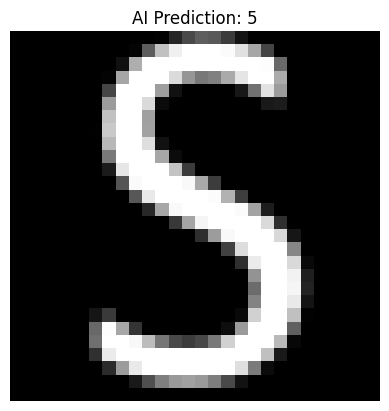

In [6]:
# --- YOUR CUSTOM IMAGE PORTAL ---
# Paste your Kaggle dataset file path below:
my_image_path = '/kaggle/input/datasets/tejasbhalekar1/sample/s.png' 

try:
    # 1. Open and convert to grayscale
    img = Image.open(my_image_path).convert('L')
    
    # 2. Resize to 28x28
    img = img.resize((28, 28))
    
    # 3. Convert to array, invert colors, and normalize
    img_array = np.array(img)
    img_array = 255 - img_array 
    img_array = img_array / 255.0 
    
    # 4. Reshape for CNN
    img_array = img_array.reshape(1, 28, 28, 1)
    
    # 5. Predict
    prediction = model.predict(img_array)
    result = np.argmax(prediction)
    
    # 6. Display the result
    plt.imshow(img_array.reshape(28,28), cmap='gray')
    plt.title(f"AI Prediction: {result}")
    plt.axis('off')
    plt.show()
    
except FileNotFoundError:
    print("⚠️ Error: Image not found. Please check your file path!")

In [7]:
# --- UPGRADED ARCHITECTURE FOR EMNIST (ALPHABETS A-Z) ---
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense

# Building the new brain for letters
model_alphabets = Sequential([
    # The 'Eyes' remain the same
    Conv2D(32, (3, 3), activation='relu', input_shape=(28, 28, 1)),
    MaxPooling2D((2, 2)),
    
    # The 'Logic' remains the same
    Flatten(),
    Dense(128, activation='relu'),
    
    # THE UPGRADE: 26 output buckets for 26 letters (A-Z) instead of 10!
    Dense(26, activation='softmax') 
])

model_alphabets.compile(optimizer='adam', 
              loss='sparse_categorical_crossentropy', 
              metrics=['accuracy'])

print("✅ Alphabet CNN Architecture Built with 26 Output Buckets!")
model_alphabets.summary()

✅ Alphabet CNN Architecture Built with 26 Output Buckets!


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_1 (Conv2D)               │ (None, 26, 26, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 13, 13, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 5408)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 128)            │       692,352 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 26)             │         3,354 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 696,026 (2.66 MB)

 Trainable params: 696,026 (2.66 MB)

 Non-trainable params: 0 (0.00 B)

In [8]:
# 1. Install the EMNIST dataset library directly into Kaggle
!pip install emnist

import numpy as np
import matplotlib.pyplot as plt
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense
from emnist import extract_training_samples, extract_test_samples

print("📥 Downloading A-Z Alphabet Flashcards...")

# 2. Load the EMNIST 'letters' dataset
x_train, y_train = extract_training_samples('letters')
x_test, y_test = extract_test_samples('letters')

# EMNIST labels letters from 1 to 26. 
# Neural networks prefer to start counting at 0, so we subtract 1 (A=0, B=1... Z=25)
y_train = y_train - 1
y_test = y_test - 1

# 3. Preprocess the images (Shrink to 0.0-1.0 and reshape)
x_train = x_train / 255.0
x_test = x_test / 255.0
x_train = x_train.reshape(-1, 28, 28, 1)
x_test = x_test.reshape(-1, 28, 28, 1)

# 4. Build the Alphabet Brain
model_alpha = Sequential([
    Conv2D(32, (3, 3), activation='relu', input_shape=(28, 28, 1)),
    MaxPooling2D((2, 2)),
    Flatten(),
    Dense(128, activation='relu'),
    Dense(26, activation='softmax') # 26 Output Buckets for A-Z!
])

model_alpha.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])

# 5. Train the AI on the Alphabet
print("🧠 Training the AI on Alphabets... (This might take a minute)")
model_alpha.fit(x_train, y_train, epochs=5, validation_split=0.1)

print("\n✅ ALPHABET MODEL TRAINED AND READY!")

📥 Downloading A-Z Alphabet Flashcards...


BadZipFile: File is not a zip file

In [ ]:
import tensorflow as tf
import tensorflow_datasets as tfds
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image

# 1. Download EMNIST Letters (A-Z) safely via TFDS
print("📥 Downloading A-Z Alphabet Dataset (EMNIST)...")
# We use 'letters' which contains 26 classes (A-Z)
ds_train, ds_info = tfds.load('emnist/letters', split='train', with_info=True, as_supervised=True)
ds_test = tfds.load('emnist/letters', split='test', as_supervised=True)

# 2. Preprocess function
# EMNIST images are famously transposed (flipped) by default, we fix that here.
def preprocess(image, label):
    image = tf.cast(image, tf.float32) / 255.0  # Normalize
    image = tf.image.transpose(image)           # Fix rotation
    return image, label - 1                     # Shift labels to 0-25 (A=0, B=1...)

train_batches = ds_train.map(preprocess).batch(32)
test_batches = ds_test.map(preprocess).batch(32)

# 3. Build the 26-Bucket Alphabet Brain
model_alpha = tf.keras.models.Sequential([
    tf.keras.layers.Conv2D(32, (3, 3), activation='relu', input_shape=(28, 28, 1)),
    tf.keras.layers.MaxPooling2D((2, 2)),
    tf.keras.layers.Flatten(),
    tf.keras.layers.Dense(128, activation='relu'),
    tf.keras.layers.Dense(26, activation='softmax') # 26 outputs for A-Z
])

model_alpha.compile(optimizer='adam', 
                    loss='sparse_categorical_crossentropy', 
                    metrics=['accuracy'])

# 4. Train the AI
print("🧠 Training on Alphabets... (5 Epochs)")
model_alpha.fit(train_batches, epochs=5)

print("\n✅ ALPHABET MODEL READY!")